# E-commerce Return Rate Reduction Analysis

## Exploratory Data Analysis (EDA)

This notebook explores customer return patterns in an e-commerce dataset. The objective is to identify factors influencing product returns and prepare the data for predictive modeling and dashboard development.

In [1]:
# =====================================================
# Import Required Libraries
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)

# Plot settings
plt.style.use('ggplot')

# Display plots inside notebook
%matplotlib inline

## Load the Cleaned Dataset

Load the cleaned e-commerce dataset and convert the date columns into datetime format for further analysis.

In [2]:
# =====================================================
# Load Dataset
# =====================================================

df = pd.read_csv("cleaned_ecommerce_dataset.csv")

# Convert date columns
date_columns = ["order_date", "delivered_date", "request_date"]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors='coerce')

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


## Basic Data Exploration

This section provides an overview of the dataset, including its dimensions, structure, and sample records.

In [3]:
# =====================================================
# Basic Data Exploration
# =====================================================

print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

Number of Rows    : 34500
Number of Columns : 19

Column Names:
['order_id', 'customer_id', 'product_id', 'category', 'price', 'discount', 'quantity', 'payment_method', 'order_date', 'delivered_date', 'region', 'returned', 'request_date', 'return_reason', 'total_amount', 'shipping_cost', 'profit_margin', 'customer_age', 'customer_gender']

First 5 Rows:


,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivered_date,region,returned,request_date,return_reason,total_amount,shipping_cost,profit_margin,customer_age,customer_gender
0,O100000,C17270,P234890,Home,164.08,0.15,1,Credit Card,2023-12-23,2023-12-27,West,No,NaT,No Return,139.47,7.88,31.17,60,Female
1,O100001,C17603,P228204,Grocery,24.73,0.00,1,Credit Card,2025-04-03,2025-04-09,South,No,NaT,No Return,24.73,4.60,-2.62,37,Male
2,O100002,C10860,P213892,Electronics,175.58,0.05,1,Credit Card,2024-10-08,2024-10-12,North,No,NaT,No Return,166.80,6.58,13.44,34,Male
3,O100003,C15390,P208689,Electronics,63.67,0.00,1,Upi,2024-09-14,2024-09-20,South,No,NaT,No Return,63.67,5.50,2.14,21,Female
4,O100004,C15226,P228063,Home,16.33,0.15,1,Cod,2024-12-21,2024-12-27,East,No,NaT,No Return,13.88,2.74,1.15,39,Male


In [4]:
# Dataset Information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34500 entries, 0 to 34499
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   order_id         34500 non-null  str           
 1   customer_id      34500 non-null  str           
 2   product_id       34500 non-null  str           
 3   category         34500 non-null  str           
 4   price            34500 non-null  float64       
 5   discount         34500 non-null  float64       
 6   quantity         34500 non-null  int64         
 7   payment_method   34500 non-null  str           
 8   order_date       34500 non-null  datetime64[us]
 9   delivered_date   34500 non-null  datetime64[us]
 10  region           34500 non-null  str           
 11  returned         34500 non-null  str           
 12  request_date     1903 non-null   datetime64[us]
 13  return_reason    34500 non-null  str           
 14  total_amount     34500 non-null  float64       
 

In [5]:
# Summary Statistics

display(df.describe())

,price,discount,quantity,order_date,delivered_date,request_date,total_amount,shipping_cost,profit_margin,customer_age
count,34500.000000,34500.000000,34500.000000,34500,34500,1903,34500.000000,34500.000000,34500.000000,34500.000000
mean,119.391632,0.049291,1.490725,2024-09-13 13:39:17.843478,2024-09-18 09:11:44.973913,2024-10-07 15:36:02.270099,170.008494,6.152120,28.116505,43.474377
min,1.010000,0.000000,1.000000,2023-09-12 00:00:00,2023-09-15 00:00:00,2023-09-24 00:00:00,0.820000,0.000000,-6.200000,18.000000
25%,16.690000,0.000000,1.000000,2024-03-14 00:00:00,2024-03-19 00:00:00,2024-04-08 12:00:00,19.710000,4.420000,1.500000,31.000000
50%,45.660000,0.000000,1.000000,2024-09-16 00:00:00,2024-09-21 00:00:00,2024-10-09 00:00:00,56.820000,6.090000,10.550000,43.000000
75%,130.950000,0.100000,2.000000,2025-03-17 00:00:00,2025-03-21 00:00:00,2025-04-11 12:00:00,168.530000,7.830000,33.132500,56.000000
max,2930.470000,0.300000,5.000000,2025-09-11 00:00:00,2025-09-21 00:00:00,2025-10-17 00:00:00,12931.800000,15.650000,1536.170000,69.000000
std,195.620477,0.069894,0.932270,NaN,NaN,NaN,357.503014,2.389539,53.352947,14.980682


In [7]:
# Summary Statistics for Categorical Columns

categorical_cols = df.select_dtypes(include=['object', 'string']).columns

display(df[categorical_cols].describe())

,order_id,customer_id,product_id,category,payment_method,region,returned,return_reason,customer_gender
count,34500,34500,34500,34500,34500,34500,34500,34500,34500
unique,34500,7903,24912,7,6,5,2,6,3
top,O100000,C11573,P200645,Fashion,Credit Card,South,No,No Return,Female
freq,1,13,7,6254,12170,7584,32597,32597,16818


## Data Quality Verification

Verify that the cleaned dataset contains no duplicate records and identify any remaining missing values.

In [8]:
# =====================================================
# Missing Values
# =====================================================

missing = df.isnull().sum()

missing = missing[missing > 0]

if missing.empty:
    print("✅ No Missing Values Found")
else:
    display(missing)

request_date    32597
dtype: int64

In [9]:
# =====================================================
# Duplicate Records
# =====================================================

duplicates = df.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

Duplicate Rows : 0


## Univariate Analysis

Univariate Analysis examines the distribution of individual numerical variables. It helps identify the spread, central tendency, skewness, and potential outliers in the dataset.

The following numerical features are analyzed:

- Price
- Quantity
- Discount
- Customer Age
- Profit Margin

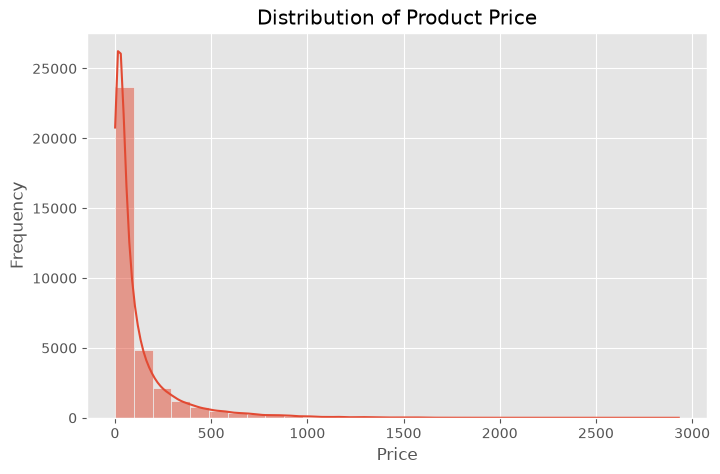

In [10]:
# =====================================================
# Distribution of Product Price
# =====================================================

plt.figure(figsize=(8,5))

sns.histplot(df['price'], bins=30, kde=True)

plt.title("Distribution of Product Price")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

### Insight

- The histogram shows how product prices are distributed.
- It helps identify whether most products are low-priced, high-priced, or evenly distributed.
- Any long tails may indicate the presence of premium-priced products.

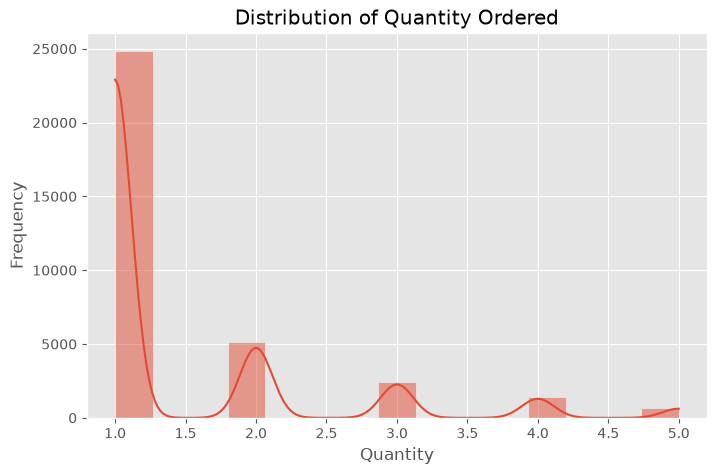

In [11]:
# =====================================================
# Distribution of Quantity
# =====================================================

plt.figure(figsize=(8,5))

sns.histplot(df['quantity'], bins=15, kde=True)

plt.title("Distribution of Quantity Ordered")
plt.xlabel("Quantity")
plt.ylabel("Frequency")

plt.show()

### Insight

- This chart shows the number of items customers purchase per order.
- It helps identify common purchasing patterns and unusual order quantities.

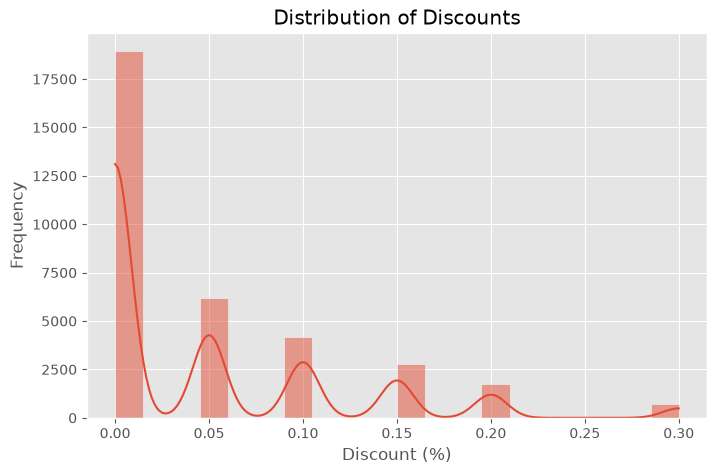

In [12]:
# =====================================================
# Distribution of Discount
# =====================================================

plt.figure(figsize=(8,5))

sns.histplot(df['discount'], bins=20, kde=True)

plt.title("Distribution of Discounts")
plt.xlabel("Discount (%)")
plt.ylabel("Frequency")

plt.show()

### Insight

- The distribution illustrates how discounts are applied across orders.
- It helps determine whether most products receive low, moderate, or high discounts.

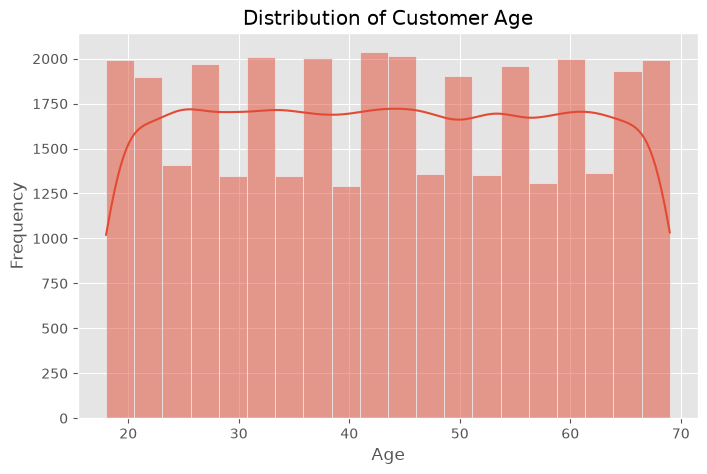

In [13]:
# =====================================================
# Distribution of Customer Age
# =====================================================

plt.figure(figsize=(8,5))

sns.histplot(df['customer_age'], bins=20, kde=True)

plt.title("Distribution of Customer Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

### Insight

- This chart highlights the age distribution of customers.
- It provides an overview of the primary customer age groups.

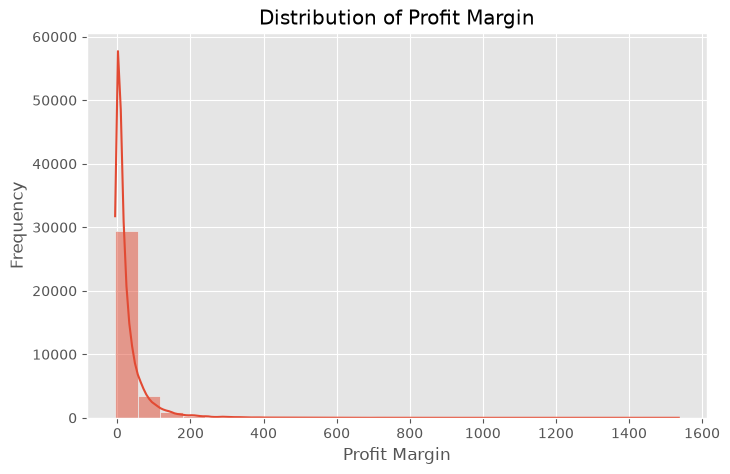

In [14]:
# =====================================================
# Distribution of Profit Margin
# =====================================================

plt.figure(figsize=(8,5))

sns.histplot(df['profit_margin'], bins=25, kde=True)

plt.title("Distribution of Profit Margin")
plt.xlabel("Profit Margin")
plt.ylabel("Frequency")

plt.show()

### Insight

- This distribution shows how profit margins vary across products.
- It helps identify whether most products generate low, moderate, or high profitability.

## Categorical Analysis

Categorical Analysis examines the distribution of categorical variables in the dataset. This helps understand customer demographics, product categories, payment methods, return status, and return reasons.

The following categorical features are analyzed:

- Product Category
- Region
- Payment Method
- Customer Gender
- Returned Status
- Return Reason

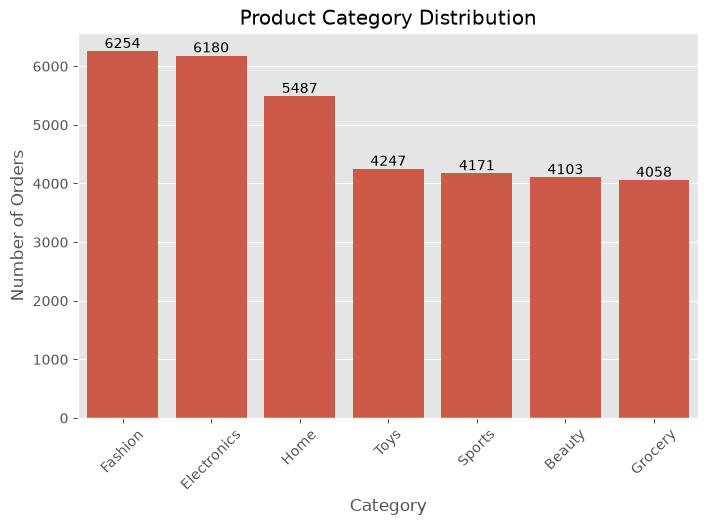

In [15]:
# =====================================================
# Product Category Distribution
# =====================================================

plt.figure(figsize=(8,5))

ax = sns.countplot(data=df,
                   x='category',
                   order=df['category'].value_counts().index)

plt.title("Product Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Insight

This chart shows the number of orders placed for each product category and highlights the most popular categories.

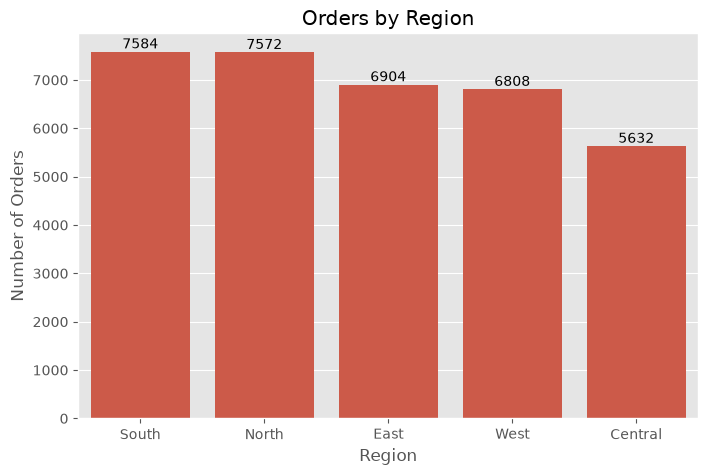

In [16]:
# =====================================================
# Region Distribution
# =====================================================

plt.figure(figsize=(8,5))

ax = sns.countplot(data=df,
                   x='region',
                   order=df['region'].value_counts().index)

plt.title("Orders by Region")
plt.xlabel("Region")
plt.ylabel("Number of Orders")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Insight

This visualization shows the geographical distribution of customer orders across different regions.

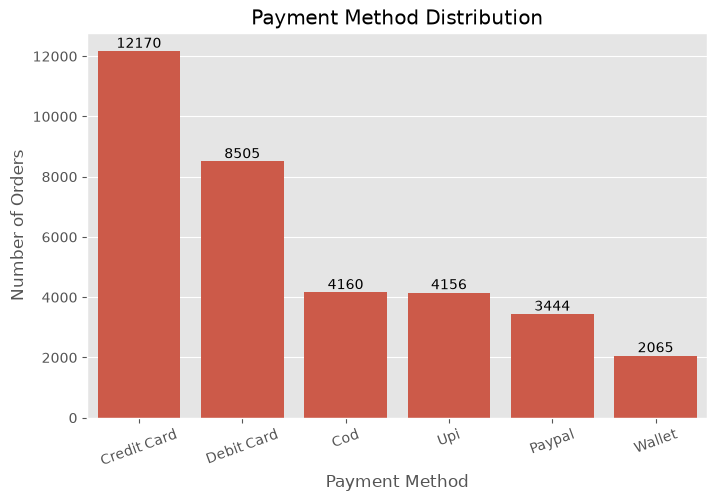

In [17]:
# =====================================================
# Payment Method Distribution
# =====================================================

plt.figure(figsize=(8,5))

ax = sns.countplot(data=df,
                   x='payment_method',
                   order=df['payment_method'].value_counts().index)

plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")

plt.xticks(rotation=20)

for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Insight

This chart displays the preferred payment methods used by customers.

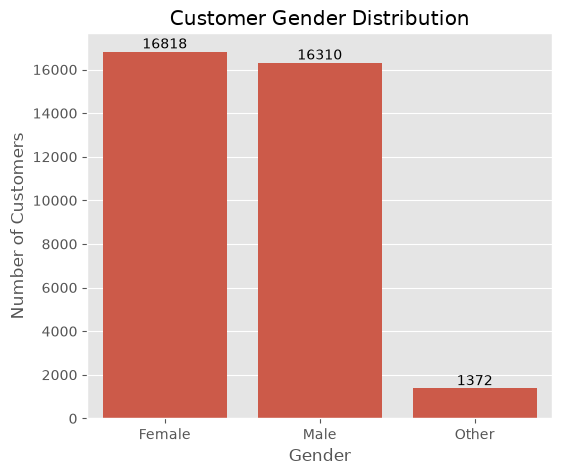

In [18]:
# =====================================================
# Customer Gender Distribution
# =====================================================

plt.figure(figsize=(6,5))

ax = sns.countplot(data=df,
                   x='customer_gender')

plt.title("Customer Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Insight

The chart provides an overview of the gender distribution of customers in the dataset.

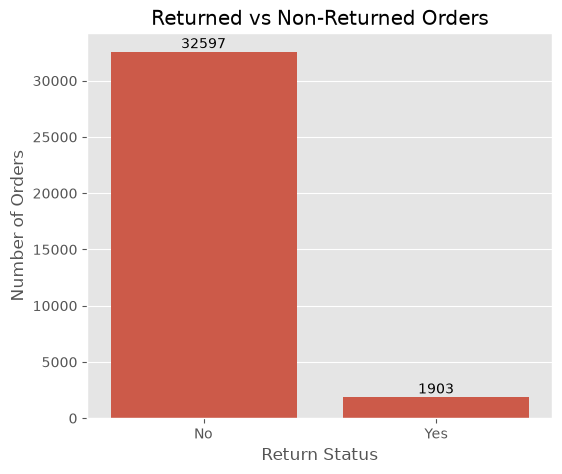

In [19]:
# =====================================================
# Returned Orders Distribution
# =====================================================

plt.figure(figsize=(6,5))

ax = sns.countplot(data=df,
                   x='returned')

plt.title("Returned vs Non-Returned Orders")
plt.xlabel("Return Status")
plt.ylabel("Number of Orders")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Insight

This visualization compares returned and non-returned orders, providing an overview of the overall return distribution.

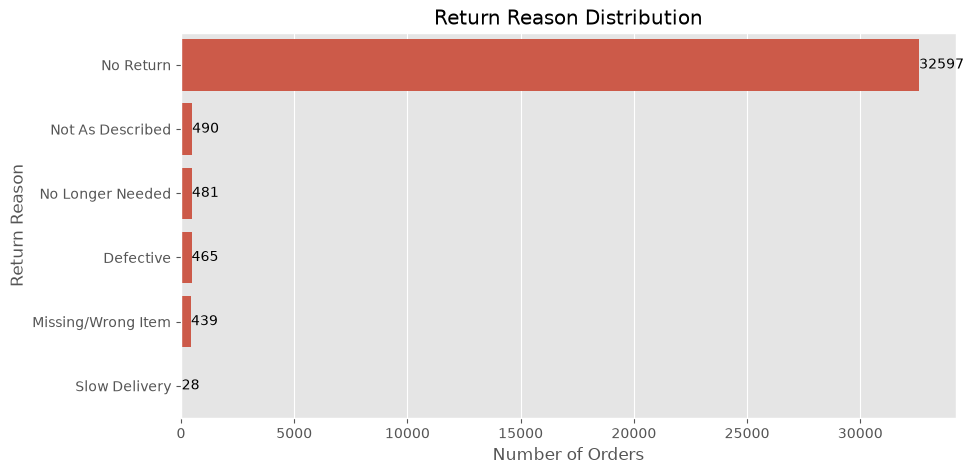

In [20]:
# =====================================================
# Return Reason Distribution
# =====================================================

plt.figure(figsize=(10,5))

ax = sns.countplot(
    data=df,
    y='return_reason',
    order=df['return_reason'].value_counts().index
)

plt.title("Return Reason Distribution")
plt.xlabel("Number of Orders")
plt.ylabel("Return Reason")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Insight

This chart identifies the most common reasons for product returns and provides valuable insights into customer dissatisfaction.

## Bivariate Analysis

Bivariate Analysis examines the relationship between two variables. In this project, it helps identify the factors that influence product returns by comparing numerical and categorical features with the return status.

The following analyses are performed:

- Discount vs Returned
- Price vs Returned
- Quantity vs Returned
- Profit Margin vs Returned
- Customer Age vs Returned

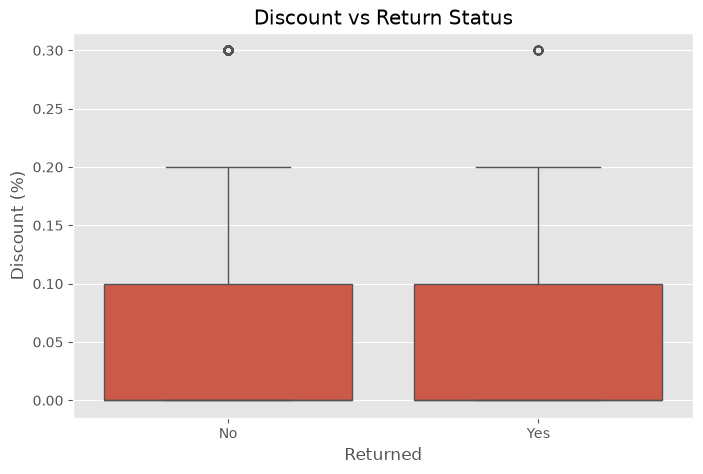

In [21]:
# =====================================================
# Discount vs Return Status
# =====================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="returned",
    y="discount"
)

plt.title("Discount vs Return Status")
plt.xlabel("Returned")
plt.ylabel("Discount (%)")

plt.show()

### Insight

This boxplot compares discounts for returned and non-returned orders. It helps determine whether higher discounts are associated with an increased likelihood of returns.

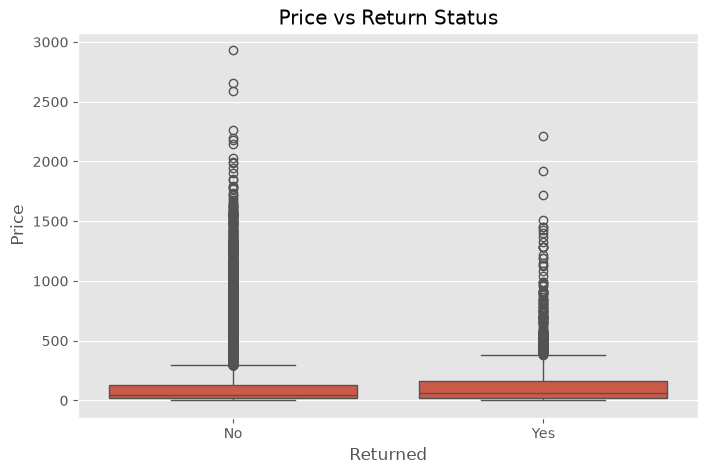

In [22]:
# =====================================================
# Price vs Return Status
# =====================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="returned",
    y="price"
)

plt.title("Price vs Return Status")
plt.xlabel("Returned")
plt.ylabel("Price")

plt.show()

### Insight

This visualization compares product prices for returned and non-returned orders to identify whether expensive products are returned more frequently.

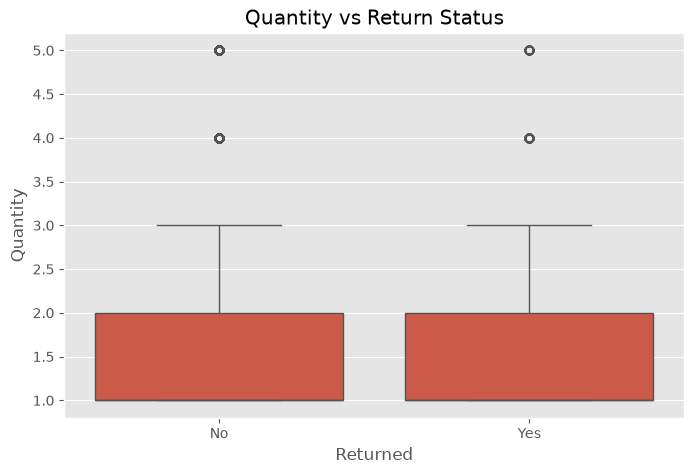

In [23]:
# =====================================================
# Quantity vs Return Status
# =====================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="returned",
    y="quantity"
)

plt.title("Quantity vs Return Status")
plt.xlabel("Returned")
plt.ylabel("Quantity")

plt.show()

### Insight

This chart examines whether order quantity influences the likelihood of product returns.

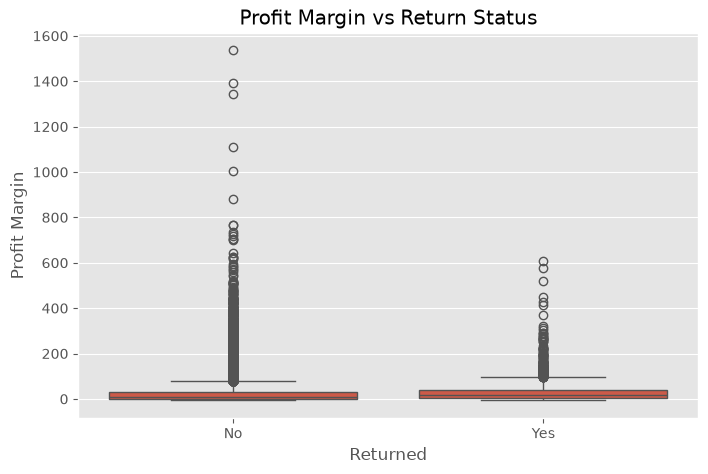

In [24]:
# =====================================================
# Profit Margin vs Return Status
# =====================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="returned",
    y="profit_margin"
)

plt.title("Profit Margin vs Return Status")
plt.xlabel("Returned")
plt.ylabel("Profit Margin")

plt.show()

### Insight

This analysis compares the profit margins of returned and non-returned products, helping assess the financial impact of returns.

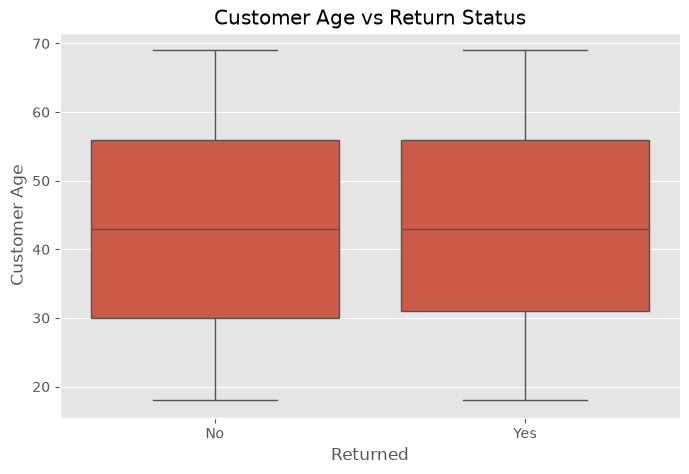

In [25]:
# =====================================================
# Customer Age vs Return Status
# =====================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="returned",
    y="customer_age"
)

plt.title("Customer Age vs Return Status")
plt.xlabel("Returned")
plt.ylabel("Customer Age")

plt.show()

### Insight

This visualization explores whether customer age has any relationship with return behavior.

# Return Rate Analysis

This section calculates and visualizes return rates across different business dimensions. The analysis helps identify which categories, regions, and payment methods experience the highest percentage of product returns.

The following analyses are performed:

- Return Rate by Category
- Return Rate by Region
- Return Rate by Payment Method
- Monthly Return Trend

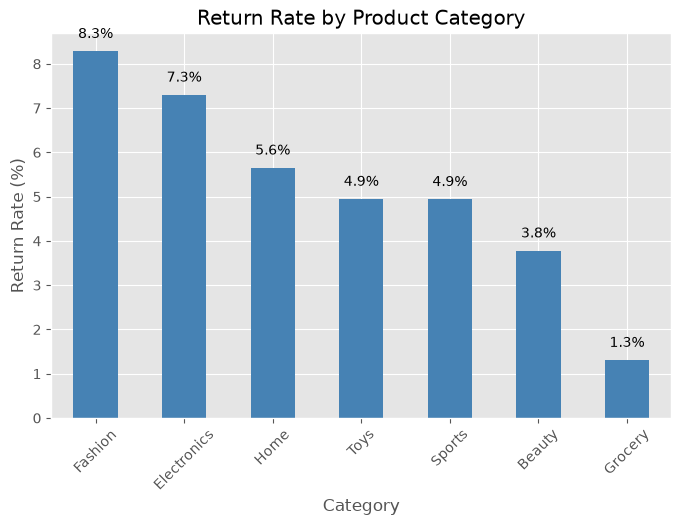

In [26]:
# =====================================================
# Return Rate by Category
# =====================================================

category_return = (
    df.groupby("category")["returned"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

ax = category_return.plot(
    kind="bar",
    color="steelblue"
)

plt.title("Return Rate by Product Category")
plt.xlabel("Category")
plt.ylabel("Return Rate (%)")
plt.xticks(rotation=45)

for i, value in enumerate(category_return):
    plt.text(i, value + 0.3, f"{value:.1f}%", ha='center')

plt.show()

### Insight

This chart identifies the product categories with the highest return rates, helping businesses focus on categories that may require quality improvements or better product descriptions.

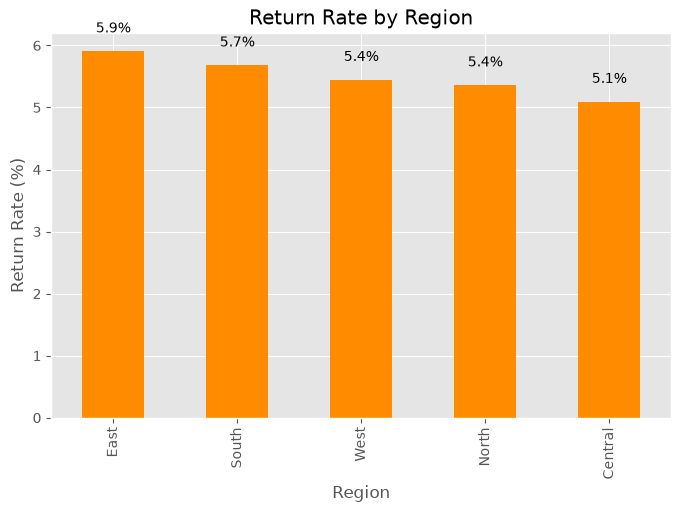

In [27]:
# =====================================================
# Return Rate by Region
# =====================================================

region_return = (
    df.groupby("region")["returned"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

ax = region_return.plot(
    kind="bar",
    color="darkorange"
)

plt.title("Return Rate by Region")
plt.xlabel("Region")
plt.ylabel("Return Rate (%)")

for i, value in enumerate(region_return):
    plt.text(i, value + 0.3, f"{value:.1f}%", ha='center')

plt.show()

### Insight

The chart compares return rates across different regions, highlighting areas where returns are more frequent and may require operational improvements.

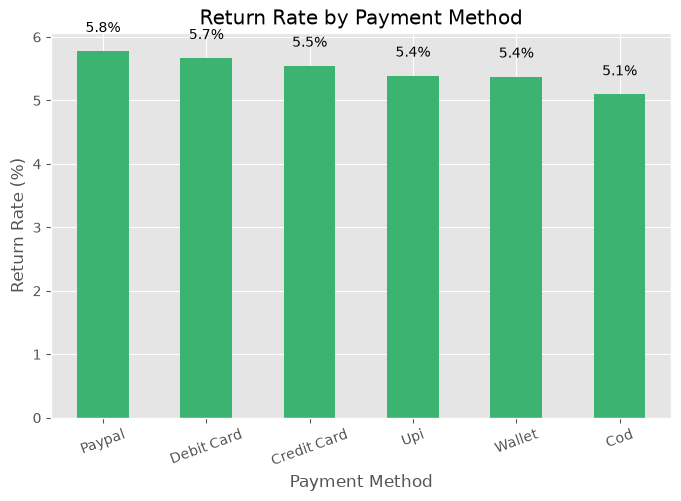

In [28]:
# =====================================================
# Return Rate by Payment Method
# =====================================================

payment_return = (
    df.groupby("payment_method")["returned"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

ax = payment_return.plot(
    kind="bar",
    color="mediumseagreen"
)

plt.title("Return Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Return Rate (%)")

plt.xticks(rotation=20)

for i, value in enumerate(payment_return):
    plt.text(i, value + 0.3, f"{value:.1f}%", ha='center')

plt.show()

### Insight

This visualization compares return rates across payment methods to identify whether certain payment options are associated with higher return percentages.

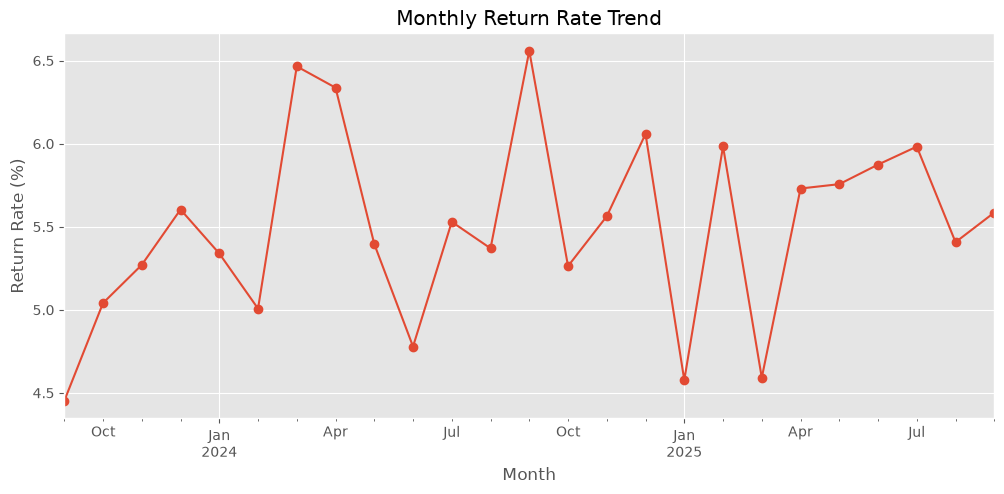

In [29]:
# =====================================================
# Monthly Return Trend
# =====================================================

df["YearMonth"] = df["order_date"].dt.to_period("M")

monthly_return = (
    df.groupby("YearMonth")["returned"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

plt.figure(figsize=(12,5))

monthly_return.plot(marker="o")

plt.title("Monthly Return Rate Trend")
plt.xlabel("Month")
plt.ylabel("Return Rate (%)")
plt.grid(True)

plt.show()

### Insight

The monthly trend helps identify seasonal patterns in product returns and reveals whether return rates are increasing, decreasing, or remaining stable over time.

# Correlation Analysis

Correlation analysis measures the strength of relationships between numerical variables. It helps identify variables that may influence return behavior and supports feature selection for the machine learning model.

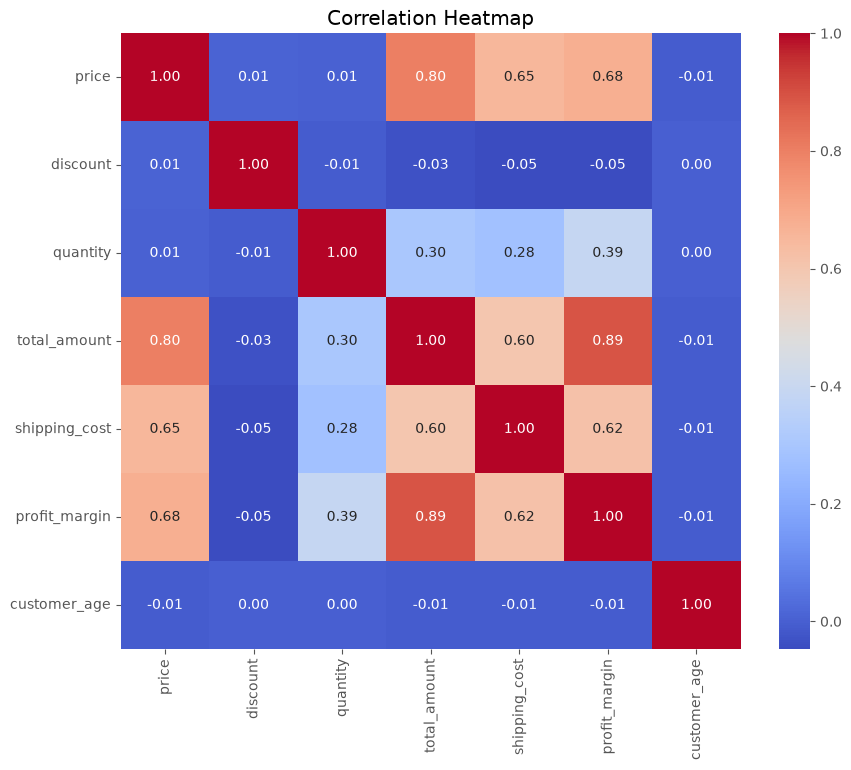

In [30]:
# =====================================================
# Correlation Heatmap
# =====================================================

numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### Insight

The correlation heatmap highlights relationships among numerical features such as price, discount, quantity, shipping cost, profit margin, and customer age. Strong correlations can help in selecting features for the predictive model.

# Key Business Insights

Based on the exploratory data analysis, the following key insights were identified:

1. Certain product categories experience higher return rates than others, indicating possible quality or customer expectation issues.

2. Return rates vary across different regions, suggesting geographical differences in customer behavior or logistics.

3. Payment methods show slight variations in return rates, which may reflect differences in purchasing patterns.

4. Higher discounts may be associated with increased return likelihood, requiring further investigation.

5. Customer demographics such as age and gender provide additional insights into return behavior.

6. Monthly return trends help identify seasonal fluctuations and periods with increased return activity.

These findings provide valuable business insights and will be used to build a predictive machine learning model for identifying high-risk returns.